# **Dataset Peparation and QC for the pretrained ViT-MAE deep learning model**

In [ ]:
# Import Libraries

import random
from pathlib import Path

import h5py
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch.utils.data import DataLoader
from torchvision import transforms

from scportrait.tools.ml.datasets import H5ScSingleCellDataset

In [2]:
# Configuration

# Path to extracted single-cell images
DATA_PATH = Path(
    "../data/interim/10x_xenium_breast_cancer_rep1_dapisegmentation_cropped_project/extraction/data/single_cells.h5sc"
)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", DEVICE)

Device: cpu


In [4]:
# Inspect the extracted single-cell dataset
dataset_raw = H5ScSingleCellDataset(
    dir_list=[DATA_PATH],
    dir_labels=[0],
    return_id=True
)

Total single cell records: 4063


In [5]:
# Read metadata from the H5SC file to get channel names and types
with h5py.File(DATA_PATH, "r") as f:

    channel_names = [
        x.decode()
        for x in f["uns/single_cell_images/channel_names"][()]
    ]

    channel_types = [
        x.decode()
        for x in f["uns/single_cell_images/channel_mapping"][()]
    ]

print("Channels")

for i,(n,t) in enumerate(zip(channel_names,channel_types)):
    print(i,n,t)

Channels
0 seg_all_nucleus mask
1 DAPI image_channel


In [6]:
# Inspect the first sample
img, label, cell_id = dataset_raw[0]

print("Image shape:", img.shape)
print("Label:", label)
print("Cell ID:", cell_id)

Image shape: torch.Size([2, 64, 64])
Label: tensor(0.)
Cell ID: tensor(1)


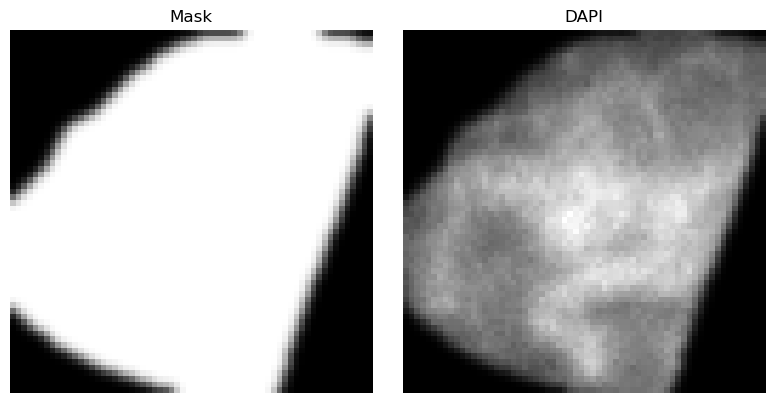

In [7]:
# Visualize all channels for first sample
fig,ax = plt.subplots(1,2,figsize=(8,4))

titles=["Mask","DAPI"]

for c in range(2):

    ax[c].imshow(img[c],cmap="gray")

    ax[c].set_title(titles[c])

    ax[c].axis("off")

plt.tight_layout()

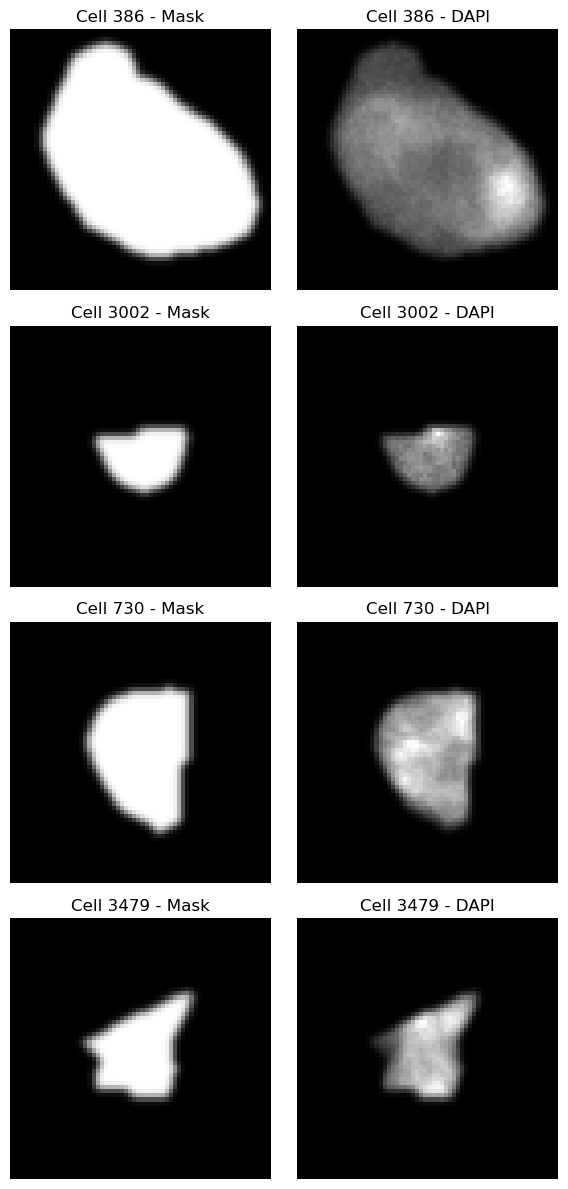

In [13]:
# Visualize random samples from the dataset
n_cells = 4

fig, axes = plt.subplots(
    n_cells,
    2,
    figsize=(6, 3 * n_cells)
)

indices = random.sample(range(len(dataset_raw)), n_cells)

for row, idx in enumerate(indices):

    img, _, _ = dataset_raw[idx]

    axes[row, 0].imshow(img[0], cmap="gray")
    axes[row, 0].set_title(f"Cell {idx} - Mask")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(img[1], cmap="gray")
    axes[row, 1].set_title(f"Cell {idx} - DAPI")
    axes[row, 1].axis("off")

plt.tight_layout()

In [ ]:
# Identify cell statistics that touch the border of the image
border_cells=[]

for i in range(len(dataset_raw)):

    img,_,_=dataset_raw[i]

    mask=img[0].numpy()

    if (
        np.any(mask[0,:]>0)
        or np.any(mask[-1,:]>0)
        or np.any(mask[:,0]>0)
        or np.any(mask[:,-1]>0)
    ):

        border_cells.append(i)

print("Border touching:",len(border_cells))

print(
    "Percentage:",
    len(border_cells)/len(dataset_raw)*100
)

Border touching: 224
Percentage: 5.51316761014029


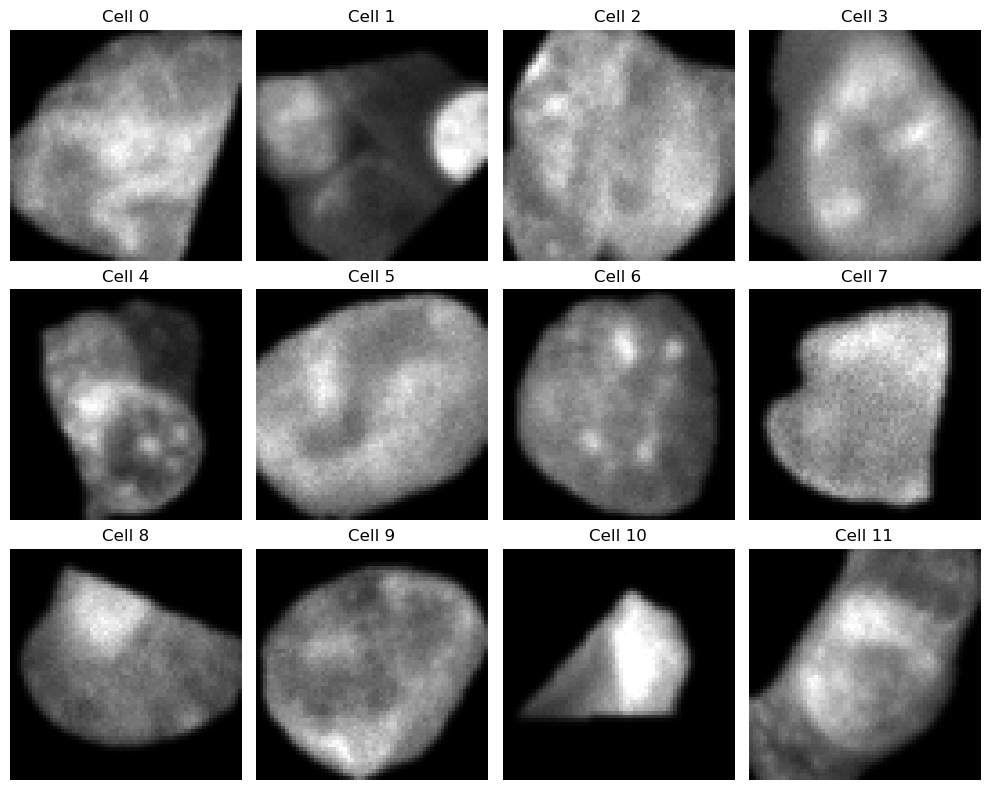

In [ ]:
# Visualize the border touching cells
fig,axes = plt.subplots(
    3,
    4,
    figsize=(10,8)
)

for ax,idx in zip(axes.flat,border_cells[:12]):

    img,_,_=dataset_raw[idx]

    ax.imshow(img[1],cmap="gray")

    ax.set_title(f"Cell {idx}")

    ax.axis("off")

plt.tight_layout()

In [17]:
# Nuclei occupancies for all cells in the dataset
occupancies=[]

for i in range(len(dataset_raw)):

    img,_,_=dataset_raw[i]

    mask=img[0].numpy()>0

    occupancies.append(mask.mean())

occupancies=np.array(occupancies)

print(f"Mean   : {occupancies.mean():.3f}")
print(f"Median : {np.median(occupancies):.3f}")
print(f"Min    : {occupancies.min():.3f}")
print(f"Max    : {occupancies.max():.3f}")

Mean   : 0.289
Median : 0.262
Min    : 0.088
Max    : 0.958


In [18]:
# Pixel intensity statistics for all cells in the dataset
pixels=[]

for i in range(len(dataset_raw)):

    img,_,_=dataset_raw[i]

    pixels.append(img[1].flatten().numpy())

pixels=np.concatenate(pixels)

print("Min :",pixels.min())
print("Max :",pixels.max())
print("Mean:",pixels.mean())
print("Std :",pixels.std())

Min : 0.0
Max : 1.0
Mean: 0.057101462
Std : 0.14435512


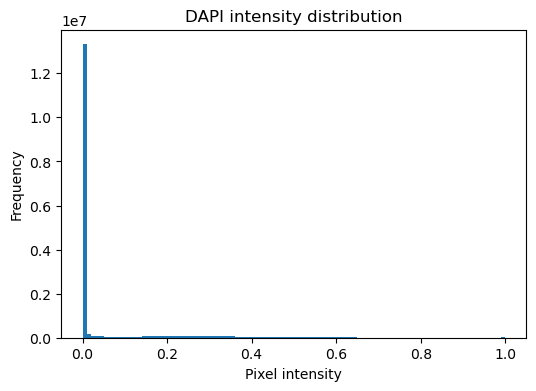

In [19]:
pixels = []

for i in range(len(dataset_raw)):
    img, _, _ = dataset_raw[i]
    pixels.append(img[1].flatten().numpy())

pixels = np.concatenate(pixels)

plt.figure(figsize=(6,4))
plt.hist(pixels, bins=100)
plt.xlabel("Pixel intensity")
plt.ylabel("Frequency")
plt.title("DAPI intensity distribution")
plt.show()

In [20]:
# Dataset preprocessing and transformation for ViT-MAE
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ConvertImageDtype(torch.float32),
])

In [21]:
# Set the DAPI channel index for further processing
DAPI_CHANNEL = [1]

# Create final dataset with transformations applied
dataset = H5ScSingleCellDataset(
    dir_list=[DATA_PATH],
    dir_labels=[0],
    select_channel=DAPI_CHANNEL,
    transform=transform,
    return_id=True,
)

Total single cell records: 4063


In [22]:
# Create a DataLoader for the dataset
loader = DataLoader(
    dataset,
    batch_size=16,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
)

In [24]:
images, labels, ids = next(iter(loader))

print("Images :", images.shape)
print("Labels :", labels.shape)
print("IDs    :", ids.shape)
print("dtype  :", images.dtype)
print("num_batches:", len(loader))

/scratch/tmurugan/conda_envs/env_scportrait/lib/python3.11/site-packages/torch/utils/data/dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Images : torch.Size([16, 1, 224, 224])
Labels : torch.Size([16])
IDs    : torch.Size([16])
dtype  : torch.float32
num_batches: 254


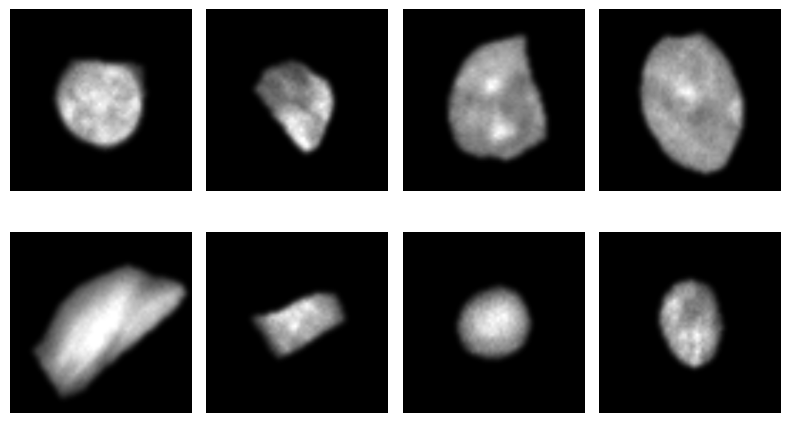

In [25]:
# Visualize processed images from the DataLoader
fig, axes = plt.subplots(2, 4, figsize=(8, 5))

for ax, img in zip(axes.flat, images):
    ax.imshow(img[0], cmap="gray")
    ax.axis("off")

plt.tight_layout()

In [28]:
# Dataset QC Summary
print("=" * 40)
print("Dataset QC Summary")
print("=" * 40)

print(f"Cells                : {len(dataset_raw)}")
print(f"Image size           : {img.shape[1]} x {img.shape[2]}")
print(f"Channels             : {channel_names}")
print(f"DAPI channel index   : {DAPI_CHANNEL}")
print(f"Border touching      : {len(border_cells)} ({len(border_cells)/len(dataset_raw)*100:.2f}%)")
print(f"Mean occupancy       : {occupancies.mean():.3f}")
print("=" * 40)

Dataset QC Summary
Cells                : 4063
Image size           : 224 x 224
Channels             : ['seg_all_nucleus', 'DAPI']
DAPI channel index   : [1]
Border touching      : 224 (5.51%)
Mean occupancy       : 0.289
